In [1]:
!pip install -q torch_snippets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.9 MB/s eta 0:00:00


In [2]:
# bibliotecas que irei usar
from torch_snippets import *
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# define o dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

# baixa o MNIST e cria os dataloaders
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('MNIST/', train=True,  transform=transforms.ToTensor(), download=True),
    batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(
    datasets.MNIST('MNIST/', train=False, transform=transforms.ToTensor(), download=True),
    batch_size=64, shuffle=False)

cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.29MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.50MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()

        # encoder convolucional
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.fc1   = nn.Linear(64*7*7, 256)
        self.fc21  = nn.Linear(256, 20)  # média
        self.fc22  = nn.Linear(256, 20)  # log variância

        # reconstrói a imagem a partir do vetor latente
        self.fc3     = nn.Linear(20, 256)
        self.fc4     = nn.Linear(256, 64*7*7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32,  1, kernel_size=3, stride=2, padding=1, output_padding=1)

    def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1) # achata
        x = F.relu(self.fc1(x))
        return self.fc21(x), self.fc22(x) # retorna mu e logvar

    def reparameterize(self, mu, logvar):
        # truque para o gradiente fluir
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std).to(device)
            return eps * std + mu
        return mu

    def decode(self, z):
        z = F.relu(self.fc3(z))
        z = F.relu(self.fc4(z))
        z = z.view(z.size(0), 64, 7, 7) # volta para formato espacial
        z = F.relu(self.deconv1(z))
        return torch.sigmoid(self.deconv2(z))

    def forward(self, x):
        mu, logvar = self.encode(x) # comprime
        z = self.reparameterize(mu, logvar) # amostra
        return self.decode(z), mu, logvar # reconstrói

In [4]:
# perda do VAE
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x, reduction='sum') # erro de reconstrução
    KLD   = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())  # regularização
    return RECON + KLD, RECON, KLD

In [5]:
# treina um batch e retorna as métricas
def train_batch(data, model, optimizer, loss_fn):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon, mu, logvar = model(data) # forward pass
    loss, mse, kld    = loss_fn(recon, data, mu, logvar) # perda combinada
    loss.backward()
    optimizer.step()
    return loss, mse, kld

# valida sem atualizar pesos
@torch.no_grad()
def validate_batch(data, model, loss_fn):
    model.eval()
    data = data.to(device)
    recon, mu, logvar = model(data)
    return loss_fn(recon, data, mu, logvar)

In [6]:
# instancia o VAE
vae = VAE().to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

EPOCH: 1.000  val_kld: 551.337  val_loss: 1886.691  train_recon: 2281.879  val_recon: 1335.354  train_loss: 2660.980  train_kld: 379.101  (81.98s - 737.79s remaining)


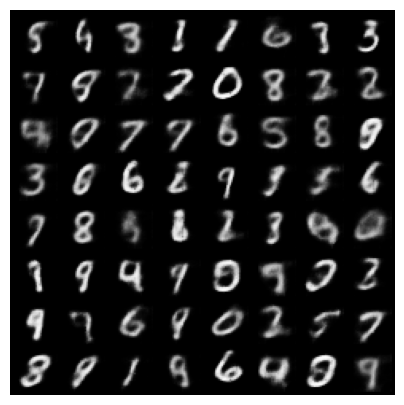

EPOCH: 2.000  val_kld: 631.034  val_loss: 1702.024  train_recon: 1452.770  val_recon: 1070.990  train_loss: 2051.499  train_kld: 598.730  (174.95s - 699.81s remaining)


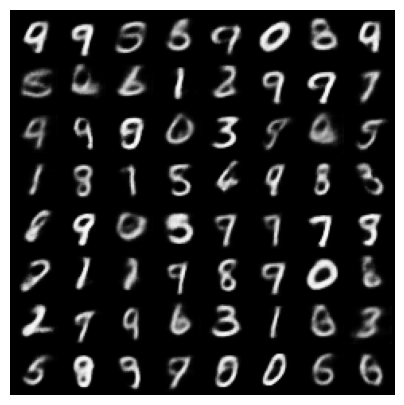

EPOCH: 3.000  val_kld: 658.488  val_loss: 1636.310  train_recon: 1293.418  val_recon: 977.822  train_loss: 1941.485  train_kld: 648.067  (268.37s - 626.19s remaining)


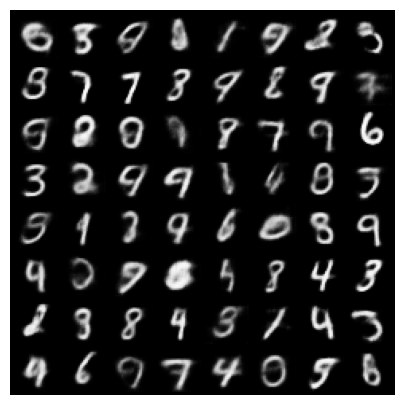

EPOCH: 4.000  val_kld: 692.551  val_loss: 1603.152  train_recon: 1218.205  val_recon: 910.601  train_loss: 1893.698  train_kld: 675.492  (360.74s - 541.10s remaining)


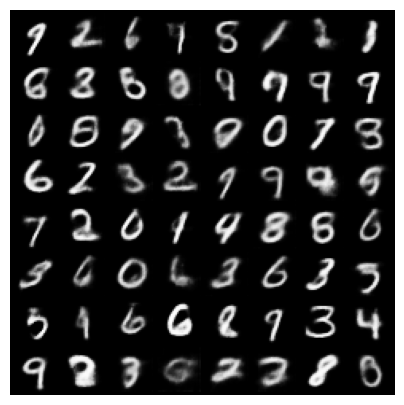

EPOCH: 5.000  val_kld: 706.661  val_loss: 1589.255  train_recon: 1171.697  val_recon: 882.594  train_loss: 1863.216  train_kld: 691.519  (452.66s - 452.66s remaining)


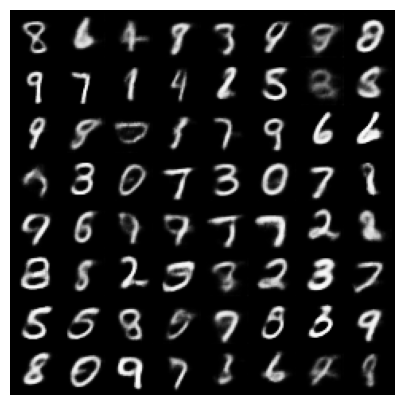

EPOCH: 6.000  val_kld: 701.630  val_loss: 1551.531  train_recon: 1138.455  val_recon: 849.901  train_loss: 1838.733  train_kld: 700.278  (545.73s - 363.82s remaining)


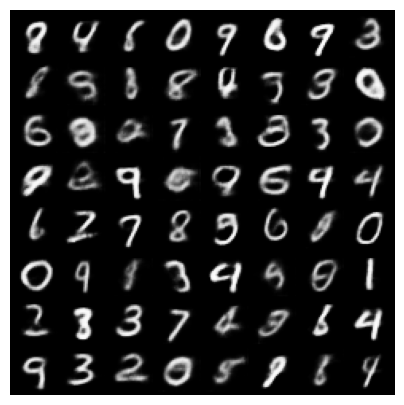

EPOCH: 7.000  val_kld: 723.113  val_loss: 1544.255  train_recon: 1114.158  val_recon: 821.143  train_loss: 1824.220  train_kld: 710.061  (641.55s - 274.95s remaining)


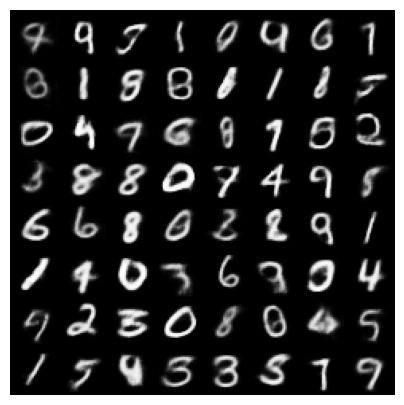

EPOCH: 8.000  val_kld: 723.418  val_loss: 1527.226  train_recon: 1092.010  val_recon: 803.809  train_loss: 1810.073  train_kld: 718.063  (735.66s - 183.91s remaining)


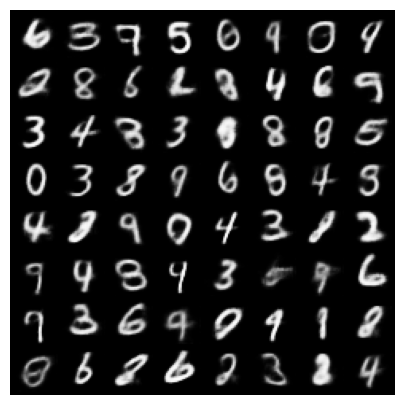

EPOCH: 9.000  val_kld: 708.509  val_loss: 1501.129  train_recon: 1076.416  val_recon: 792.620  train_loss: 1801.798  train_kld: 725.382  (831.71s - 92.41s remaining)


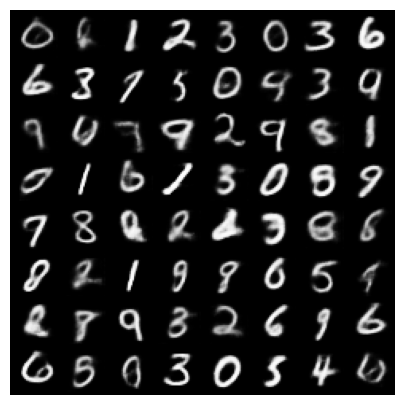

EPOCH: 10.000  val_kld: 712.589  val_loss: 1489.701  train_recon: 1059.449  val_recon: 777.112  train_loss: 1787.920  train_kld: 728.471  (926.18s - 0.00s remaining)


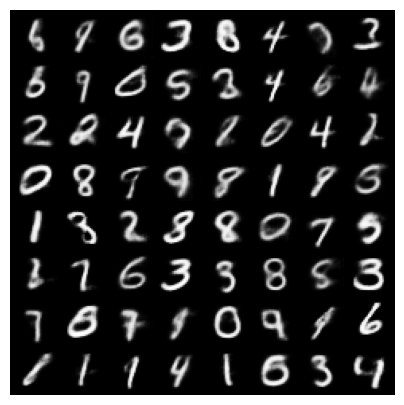

In [7]:
# loop de treinamento por 10 épocas com geração de imagens ao final de cada uma
n_epochs = 10
log = Report(n_epochs)

for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):  # treino
        loss, recon, kld = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1 + batch_idx) / N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, end='\r')

    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):   # validação
        loss, recon, kld = validate_batch(data, vae, loss_function)
        pos = epoch + (1 + batch_idx) / N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, end='\r')

    log.report_avgs(epoch + 1)  # exibe médias da época

    # gera 64 imagens a partir de vetores
    with torch.no_grad():
        z      = torch.randn(64, 20).to(device) # amostras do espaço latente
        sample = vae.decode(z) # decodifica
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1, 2, 0)
        show(images) # exibe grade de imagens geradas